# Example 05C: Compare Ensemble Outputs

This notebook compares completed sibling simulations from notebook 05B using the outlet flow-component files. The same workflow can compare one base model with many realizations, or several base models by loading multiple simulation manifests and assigning each one a `base_model` label.

In [11]:
from pathlib import Path
import sys

import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src" / "sewertris").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

EXAMPLES_DIR = PROJECT_ROOT / "examples"
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import sewertris as sp

ENSEMBLE_ROOT = EXAMPLES_DIR / "output_example_5_ensembles"
SIMULATION_MANIFEST = ENSEMBLE_ROOT / "simulation_manifest.csv"
FIGURE_PATH = ENSEMBLE_ROOT / "ensemble_outlet_flow_comparison.png"

print("Simulation manifest:", SIMULATION_MANIFEST)

Simulation manifest: /Users/kevinblanco/Documents/Sewertris/examples/output_example_5_ensembles/simulation_manifest.csv


## Load Simulation Manifests

Add more entries to `MANIFEST_SOURCES` when comparing ensembles produced from different base models. Each manifest should contain the columns written by notebook 05B, including `ensemble`, `realization`, `project_file`, and `flows_path`.

In [12]:
MANIFEST_SOURCES = [
    {
        "base_model": "Stillwater V2 base",
        "path": SIMULATION_MANIFEST,
    },
    # Example for a second base model:
    # {
    #     "base_model": "Stillwater alternate base",
    #     "path": EXAMPLES_DIR / "output_example_5_ensembles_alt" / "simulation_manifest.csv",
    # },
]

manifests = []
for source in MANIFEST_SOURCES:
    path = Path(source["path"])
    if not path.exists():
        print(f"Missing manifest: {path}")
        continue
    manifest = pd.read_csv(path)
    manifest["base_model"] = source["base_model"]
    manifest["manifest_path"] = str(path)
    manifests.append(manifest)

if manifests:
    simulation_manifest = pd.concat(manifests, ignore_index=True)
    simulation_manifest["flows_exists"] = simulation_manifest["flows_path"].map(lambda p: Path(p).exists())
    display(simulation_manifest)
else:
    simulation_manifest = pd.DataFrame()
    print("No simulation manifests were loaded. Run notebook 05B first.")

,ensemble,realization,project_file,scenario_input,flows_path,rerun_from,base_model,manifest_path,flows_exists
0,manning_variation,1,/Users/kevinblanco/Documents/Sewertris/example...,/Users/kevinblanco/Documents/Sewertris/example...,/Users/kevinblanco/Documents/Sewertris/example...,10_dynamic_flow_input_definition_base_model,Stillwater V2 base,/Users/kevinblanco/Documents/Sewertris/example...,True
1,manning_variation,2,/Users/kevinblanco/Documents/Sewertris/example...,/Users/kevinblanco/Documents/Sewertris/example...,/Users/kevinblanco/Documents/Sewertris/example...,10_dynamic_flow_input_definition_base_model,Stillwater V2 base,/Users/kevinblanco/Documents/Sewertris/example...,True
2,manning_variation,3,/Users/kevinblanco/Documents/Sewertris/example...,/Users/kevinblanco/Documents/Sewertris/example...,/Users/kevinblanco/Documents/Sewertris/example...,10_dynamic_flow_input_definition_base_model,Stillwater V2 base,/Users/kevinblanco/Documents/Sewertris/example...,True
3,seed_only,1,/Users/kevinblanco/Documents/Sewertris/example...,/Users/kevinblanco/Documents/Sewertris/example...,/Users/kevinblanco/Documents/Sewertris/example...,10_dynamic_flow_input_definition_base_model,Stillwater V2 base,/Users/kevinblanco/Documents/Sewertris/example...,True
4,seed_only,2,/Users/kevinblanco/Documents/Sewertris/example...,/Users/kevinblanco/Documents/Sewertris/example...,/Users/kevinblanco/Documents/Sewertris/example...,10_dynamic_flow_input_definition_base_model,Stillwater V2 base,/Users/kevinblanco/Documents/Sewertris/example...,True
5,seed_only,3,/Users/kevinblanco/Documents/Sewertris/example...,/Users/kevinblanco/Documents/Sewertris/example...,/Users/kevinblanco/Documents/Sewertris/example...,10_dynamic_flow_input_definition_base_model,Stillwater V2 base,/Users/kevinblanco/Documents/Sewertris/example...,True


## Ensemble Dashboard

The top four panels show outlet hydrographs for total flow, GWI, BWF/DWF, and RDII. Thin lines are individual simulations, and the heavier line is the group median with a quantile band. The bottom section uses six panels: BWF/DWF, GWI, and RDII volumes on one row, then BWF/DWF, GWI, and RDII peak flows on the next row, each with its own y-axis scale.

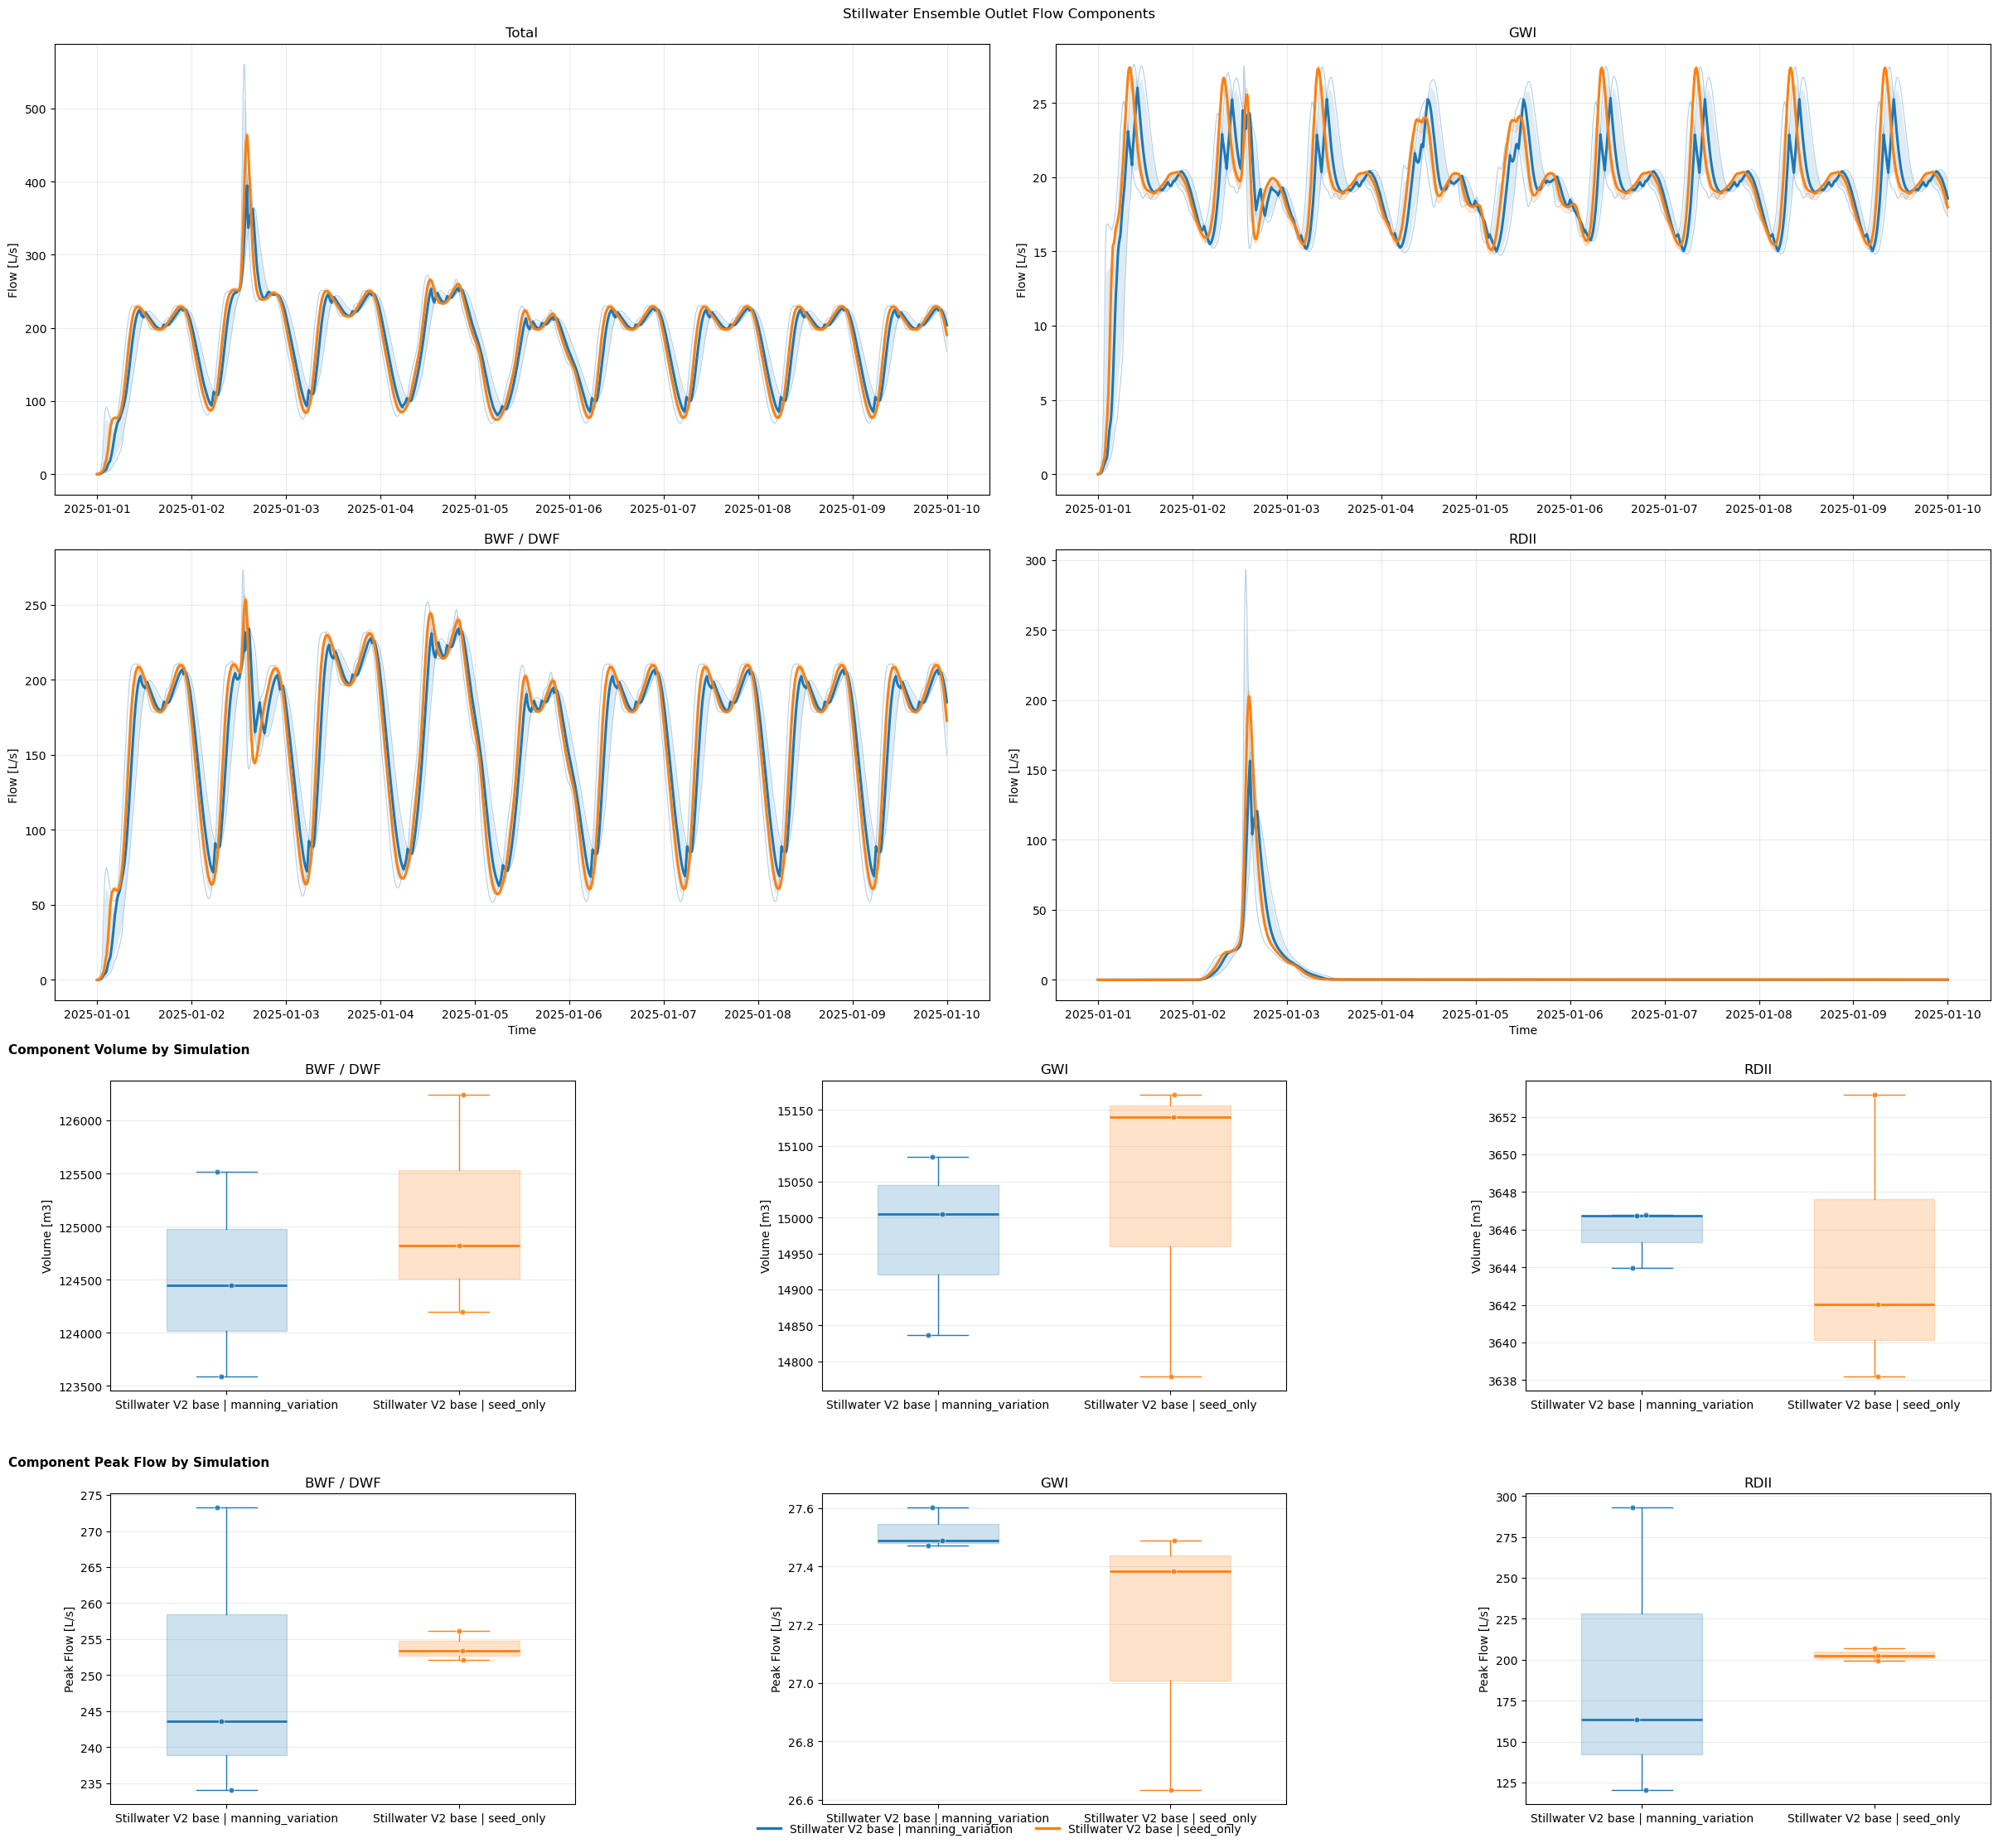

Saved figure: /Users/kevinblanco/Documents/Sewertris/examples/output_example_5_ensembles/ensemble_outlet_flow_comparison.png


,member_id,group_label,simulation_label,component,volume,peak_flow,flows_path,ensemble,realization,project_file,scenario_input,rerun_from,base_model,manifest_path,flows_exists
0,0,Stillwater V2 base | manning_variation,Stillwater V2 base | manning_variation #1,BWF / DWF,125514.852648,273.256939,/Users/kevinblanco/Documents/Sewertris/example...,manning_variation,1,/Users/kevinblanco/Documents/Sewertris/example...,/Users/kevinblanco/Documents/Sewertris/example...,10_dynamic_flow_input_definition_base_model,Stillwater V2 base,/Users/kevinblanco/Documents/Sewertris/example...,True
1,0,Stillwater V2 base | manning_variation,Stillwater V2 base | manning_variation #1,GWI,14835.855597,27.471830,/Users/kevinblanco/Documents/Sewertris/example...,manning_variation,1,/Users/kevinblanco/Documents/Sewertris/example...,/Users/kevinblanco/Documents/Sewertris/example...,10_dynamic_flow_input_definition_base_model,Stillwater V2 base,/Users/kevinblanco/Documents/Sewertris/example...,True
2,0,Stillwater V2 base | manning_variation,Stillwater V2 base | manning_variation #1,RDII,3643.950856,292.889879,/Users/kevinblanco/Documents/Sewertris/example...,manning_variation,1,/Users/kevinblanco/Documents/Sewertris/example...,/Users/kevinblanco/Documents/Sewertris/example...,10_dynamic_flow_input_definition_base_model,Stillwater V2 base,/Users/kevinblanco/Documents/Sewertris/example...,True
3,1,Stillwater V2 base | manning_variation,Stillwater V2 base | manning_variation #2,BWF / DWF,123588.266915,243.582483,/Users/kevinblanco/Documents/Sewertris/example...,manning_variation,2,/Users/kevinblanco/Documents/Sewertris/example...,/Users/kevinblanco/Documents/Sewertris/example...,10_dynamic_flow_input_definition_base_model,Stillwater V2 base,/Users/kevinblanco/Documents/Sewertris/example...,True
4,1,Stillwater V2 base | manning_variation,Stillwater V2 base | manning_variation #2,GWI,15085.012107,27.601490,/Users/kevinblanco/Documents/Sewertris/example...,manning_variation,2,/Users/kevinblanco/Documents/Sewertris/example...,/Users/kevinblanco/Documents/Sewertris/example...,10_dynamic_flow_input_definition_base_model,Stillwater V2 base,/Users/kevinblanco/Documents/Sewertris/example...,True


In [13]:
START = None
END = None

if "flows_exists" in simulation_manifest.columns:
    available_manifest = simulation_manifest.loc[simulation_manifest["flows_exists"]].copy()
else:
    available_manifest = pd.DataFrame()

if available_manifest.empty:
    print("No completed flow-component files were found. Run notebook 05B first.")
else:
    fig, ensemble_summary = sp.plot_ensemble_results(
        available_manifest,
        group_cols=("base_model", "ensemble"),
        start=START,
        end=END,
        title="Stillwater Ensemble Outlet Flow Components",
        figsize=(24, 22),
        savepath=FIGURE_PATH,
        return_summary=True,
    )
    print("Saved figure:", FIGURE_PATH)
    display(ensemble_summary.head())

## Summary Tables

In [14]:
if "ensemble_summary" in globals() and not ensemble_summary.empty:
    volume_table = ensemble_summary.pivot_table(
        index=["base_model", "ensemble", "realization"],
        columns="component",
        values="volume",
    )
    peak_table = ensemble_summary.pivot_table(
        index=["base_model", "ensemble", "realization"],
        columns="component",
        values="peak_flow",
    )

    print("Component volumes")
    display(volume_table)
    print("Component peak flows")
    display(peak_table)
else:
    print("Run the dashboard cell first.")

Component volumes


component                                             BWF / DWF           GWI  \
base_model         ensemble          realization                                
Stillwater V2 base manning_variation 1            125514.852648  14835.855597   
                                     2            123588.266915  15085.012107   
                                     3            124444.215168  15004.606252   
                   seed_only         1            124820.024174  14778.697913   
                                     2            124200.953955  15140.134367   
                                     3            126245.035279  15171.347555   

component                                                RDII  
base_model         ensemble          realization               
Stillwater V2 base manning_variation 1            3643.950856  
                                     2            3646.726530  
                                     3            3646.779375  
                   seed_only         1            3653.186920  
                                     2            3642.048529  
                                     3            3638.192752

Component peak flows


component                                          BWF / DWF        GWI  \
base_model         ensemble          realization                          
Stillwater V2 base manning_variation 1            273.256939  27.471830   
                                     2            243.582483  27.601490   
                                     3            234.081156  27.488298   
                   seed_only         1            256.147640  26.634332   
                                     2            253.313091  27.384295   
                                     3            252.096602  27.488052   

component                                               RDII  
base_model         ensemble          realization              
Stillwater V2 base manning_variation 1            292.889879  
                                     2            163.359985  
                                     3            120.626229  
                   seed_only         1            206.874278  
                                     2            202.523929  
                                     3            199.144101

In [15]:
import os

# Your code here
# ...

os.system('afplay /System/Library/Sounds/Hero.aiff')
os.system('say "Kevin, your simulation has finished."')

0